In [1]:
# def compute_P_vs_angle(scatt_angles_deg, a_max_list, a_grid, zscat, theta, res):
#     Z11eff = np.zeros((len(a_max_list), len(lambda_bands_cm), len(scatt_angles_deg)))
#     Z12eff = np.zeros_like(Z11eff)

#     distri_template = a_grid**0.5
#     distri_template /= distri_template.sum()

#     for ia, amax in enumerate(a_max_list):
#         distri = distri_template.copy()
#         distri[a_grid > amax] = 0
#         distri /= distri.sum()

#         for iw in range(len(lambda_bands_cm)):
#             z11_avg = np.sum(zscat[:, iw, :, 0] * distri[:, None], axis=0)
#             z12_avg = np.sum(zscat[:, iw, :, 1] * distri[:, None], axis=0)

#             f_z11 = interp1d(theta, z11_avg, kind='linear', fill_value="extrapolate")
#             f_z12 = interp1d(theta, z12_avg, kind='linear', fill_value="extrapolate")

#             Z11eff[ia, iw, :] = f_z11(scatt_angles_deg)
#             Z12eff[ia, iw, :] = f_z12(scatt_angles_deg)

#     return -Z12eff / Z11eff


In [2]:
# def compute_P_and_omega_vs_amax(a_max_list, zscat, res, theta):
#     i90 = theta.searchsorted(90)
#     distri_template = a_max_list**0.5
#     distri_template /= distri_template.sum()

#     Z11eff = np.zeros((len(a_max_list), len(lambda_bands_cm)))
#     Z12eff = np.zeros_like(Z11eff)
#     omega = np.zeros_like(Z11eff)

#     for ia, amax in enumerate(a_max_list):
#         distri = distri_template.copy()
#         distri[a_max_list > amax] = 0
#         distri /= distri.sum()

#         Z11eff[ia] = np.sum(zscat[:, :, i90, 0] * distri[:, None], axis=0)
#         Z12eff[ia] = np.sum(zscat[:, :, i90, 1] * distri[:, None], axis=0)

#         k_a = np.sum(res['k_abs'] * distri[:, None], axis=0)
#         k_s = np.sum(res['k_sca'] * distri[:, None], axis=0)
#         omega[ia] = k_s / (k_a + k_s)

#     P = np.abs(Z12eff / Z11eff)
    
#     P_times_omega = P * omega
    
#     return P, omega, P_times_omega


In [3]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packa

In [4]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [5]:
%matplotlib inline

## Step 1: Setup (run once)

In [6]:
# Constants
bands = ["Band 4 nterms2", "Band 5", "Band 6", "Band 7 nterms2"]
bands_naming = ['Band4_nterms2', 'Band5', 'Band6', 'Band7_nterms2']
bands_labels = ['Band 4', 'Band 5', 'Band 6', 'Band 7']

num_bands = len(bands)
 
lambda_bands_cm = mm_to_cm([lambda_mm[b] for b in bands])
band_colors = [alma_band_colors[b] for b in bands]

oc, rho_g_cm3 = do.get_dsharp_mix()

Please cite Warren & Brandt (2008) when using these optical constants
Please cite Draine 2003 when using these optical constants
Reading opacities from troilitek
Please cite Henning & Stognienko (1996) when using these optical constants
Reading opacities from organicsk
Please cite Henning & Stognienko (1996) when using these optical constants
| material                            | volume fractions | mass fractions |
|-------------------------------------|------------------|----------------|
| Water Ice (Warren & Brandt 2008)    | 0.3642           | 0.2            |
| Astronomical Silicates (Draine 2003)| 0.167            | 0.329          |
| Troilite (Henning)                  | 0.02578          | 0.07434        |
| Organics (Henning)                  | 0.443            | 0.3966         |


In [7]:
oc

In [8]:
POLF_avg = []

for band in bands:
    if band == 'Band 4':
        path = constants.band4_data_folder_path + "constants_BAND4.csv"
    elif band == 'Band 4 nterms2':
        path = constants.band4_nterms2_data_folder_path + "constants_BAND4_nterms2.csv"
    elif band == 'Band 5':
        path = constants.band5_data_folder_path + "constants_BAND5.csv"
    elif band == 'Band 6':
        path = constants.band6_data_folder_path + "constants_BAND6.csv"
    elif band == 'Band 7 nterms2':
        path = constants.band7_nterms2_data_folder_path + "constants_BAND7_nterms2.csv"
    else:
        raise ValueError("Only 'Band 4', 'Band 4 nterms2', 'Band 5', 'Band 6', and 'Band 7 nterms2' are supported.")
    
    print(rf"Now on {band}")
    df = pd.read_csv(path)
    print("Columns:", df.columns.tolist())
    
#     POLF_avg.append(df["POLF_avg"].values[0] * 100)

Now on Band 4 nterms2
Columns: ['POLF_Gaussian', 'POLF_maxPOLI', 'POLF_maxStokesI']
Now on Band 5
Columns: ['POLF_Gaussian', 'POLF_maxPOLI', 'POLF_maxStokesI']
Now on Band 6
Columns: ['POLF_Gaussian', 'POLF_maxPOLI', 'POLF_maxStokesI']
Now on Band 7 nterms2
Columns: ['POLF_Gaussian', 'POLF_maxPOLI', 'POLF_maxStokesI']


## Step 2: Figure 1 — Abs/Sca opacities vs wavelength

In [9]:
# Set up wavelength array
logwave_vals = np.linspace(0.1, 4,10000)

lambda_dist_micron = 10**logwave_vals

lambda_dist_cm = micron_to_cm(lambda_dist_micron)

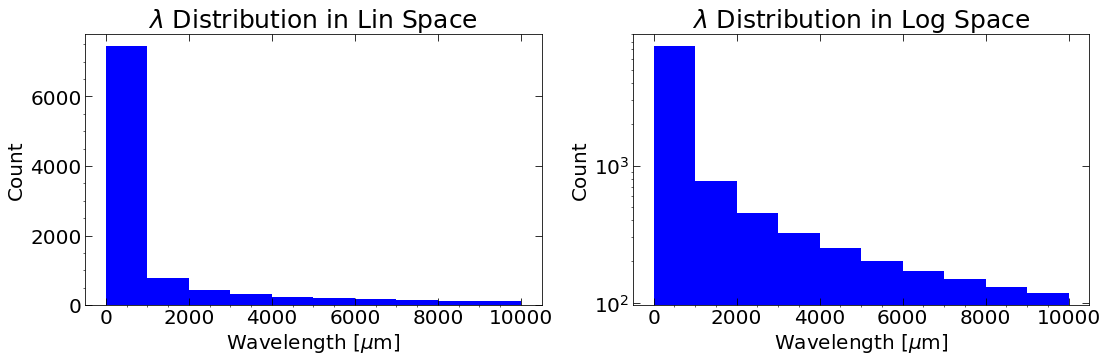

In [10]:
bins = 10

fig, ax = plt.subplots(1, 2, figsize=(18, 5))

ax[0].set_title(rf"$\lambda$ Distribution in Lin Space", fontsize = title_fs)
ax[1].set_title(rf"$\lambda$ Distribution in Log Space", fontsize = title_fs)

# Make axes log if needed
# ax[1].set_xscale('log')
ax[1].set_yscale('log')

for i in range(2):
    ax[i].hist(lambda_dist_micron, bins = bins, color = 'blue')
    
    # Add axis labels
    ax[i].set_xlabel(r'Wavelength [$\mu$m]', fontsize=axis_label_fs)
    ax[i].set_ylabel('Count', fontsize=axis_label_fs)


    # Adjust ticks
    ax[i].minorticks_on()
    ax[i].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)

# Remove scientific notation from x-axis
#     ax[i].xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
#     ax[i].ticklabel_format(style='plain', axis='x')

In [11]:
# a_max values for this plot
a_max_micron_fig1 = [1, 100]
a_max_cm_fig1 = micron_to_cm(a_max_micron_fig1)

# Run opacities once
res_fig1 = do.get_opacities(a_max_cm_fig1, lambda_dist_cm, rho_g_cm3, oc)

Mie ... Done!


In [12]:
oc

In [13]:
k_abs_fig1 = res_fig1['k_abs']
k_sca_fig1 = res_fig1['k_sca']
S1_fig1    = res_fig1['S1']
S2_fig1    = res_fig1['S2']
theta_fig1 = res_fig1['theta']

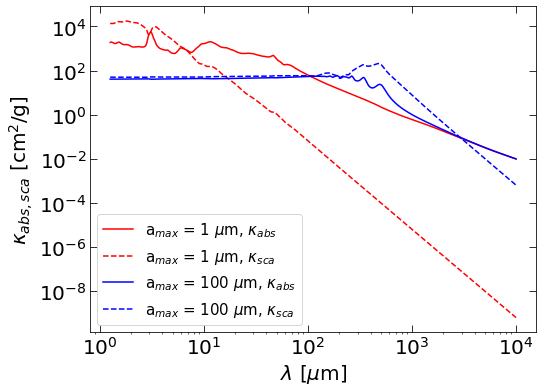

In [94]:
# Create a figure with the WCS projection
fig, ax = plt.subplots(figsize=(8, 6))

fig1_colors = ['red', 'blue']

for i in range(2):
    ax.plot(lambda_dist_micron,
            k_abs_fig1[i],
            color = fig1_colors[i],
            ls = '-',
            label = rf'a$_{{max}}$ = {a_max_micron_fig1[i]} $\mu$m, $\kappa_{{abs}}$')

    ax.plot(lambda_dist_micron,
            k_sca_fig1[i],
            color = fig1_colors[i],
            ls = '--',
            label = rf'a$_{{max}}$ = {a_max_micron_fig1[i]} $\mu$m, $\kappa_{{sca}}$')


# Add axis labels
ax.set_xlabel('$\lambda$ [$\mu$m]', fontsize=axis_label_fs)
ax.set_ylabel('$\kappa_{abs, sca}$ [cm$^2$/g]', fontsize=axis_label_fs)


# Adjust ticks
ax.minorticks_on()
ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)

ax.legend(loc = 'lower left',
          fontsize = legend_text_fs)

# Make axes log if needed
ax.set_xscale('log')
ax.set_yscale('log')

# Set axis limits
# ax.setxlim(0.11e4)
# ax.set_ylim(10e-4, 10e4)


# plt.savefig(slideshow_image_folder_path + '/DustModels/'+ "Kataoka2015Fig1.jpeg", 
#             dpi=300, 
#             bbox_inches='tight')  


plt.savefig(writeup_image_folder_path + '/DustModels/'+ "Kataoka2015Fig1.pdf", 
            dpi=300, 
            bbox_inches='tight')  

## Step 3: Shared Scattering Setup for Fig 2 & Fig 3

### Grain size distribution

In [15]:
N_grains = 200

In [16]:
a_max_dist_micron = np.logspace(np.log10(1e0), np.log10(1e4), N_grains)

a_max_dist_cm = micron_to_cm(a_max_dist_micron)

print(rf'a_max ranges from:')
print(rf'{np.min(a_max_dist_micron)} to {np.max(a_max_dist_micron)} microns or')
print(rf'{np.min(a_max_dist_cm)} to {np.max(a_max_dist_cm)} cm')

a_max ranges from:
1.0 to 10000.0 microns or
0.0001 to 1.0 cm


In [17]:
mass_grams_fig = calculate_grain_mass(a_max_dist_cm, rho_g_cm3, "cm")

In [18]:
rho_g_cm3

1.675278719712058

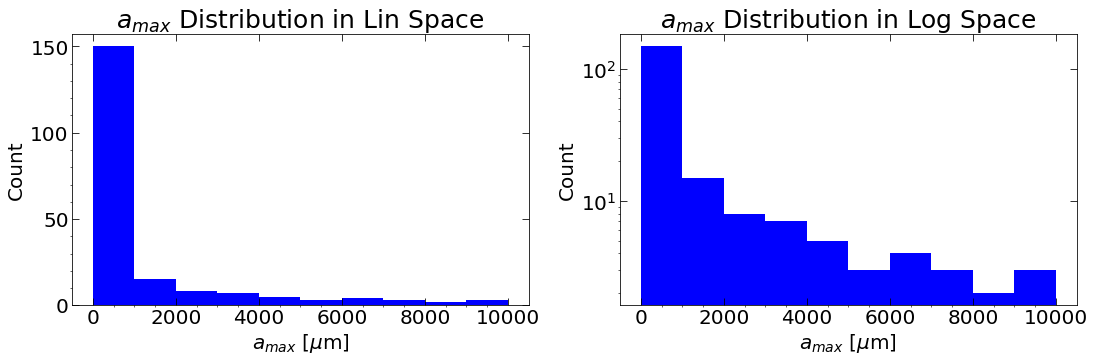

In [19]:
bins = 10

fig, ax = plt.subplots(1, 2, figsize=(18, 5))

ax[0].set_title(r"$a_{max}$ Distribution in Lin Space", fontsize = title_fs)
ax[1].set_title(r"$a_{max}$ Distribution in Log Space", fontsize = title_fs)

# Make axes log if needed
# ax[1].set_xscale('log')
ax[1].set_yscale('log')

for i in range(2):
    ax[i].hist(a_max_dist_micron, bins = bins, color = 'blue')
    
    # Add axis labels
    ax[i].set_xlabel(r'$a_{max}$ [$\mu$m]', fontsize=axis_label_fs)
    ax[i].set_ylabel('Count', fontsize=axis_label_fs)


    # Adjust ticks
    ax[i].minorticks_on()
    ax[i].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)

    # Remove scientific notation from x-axis
    ax[i].xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
    ax[i].ticklabel_format(style='plain', axis='x')

### Run opacities once for both Fig 2 and Fig 3

In [20]:
res_scatter = do.get_opacities(a_max_dist_cm, lambda_bands_cm, rho_g_cm3, oc, n_angle=100)

zscat = do.calculate_mueller_matrix(lambda_bands_cm, mass_grams_fig, 
                                    res_scatter['S1'], res_scatter['S2'], 
                                    theta=res_scatter['theta'], 
                                    k_sca=res_scatter['k_sca'])['zscat']
theta = res_scatter['theta']


Mie ... Done!


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 9.6%: above error tolerance
  warnings.warn(


### Step 4: Figure 2 — Polarization vs scattering angle

In [21]:
a_max_cm_fig2 = micron_to_cm([10, 100, 1000, 10000])

fig2_bands = [4, 7]

fig2_labels = ['10 $\mu$m', '100 $\mu$m', '1 mm', '1 cm']

scatt_angles_deg = np.linspace(0, 180, 5000)


P_eff = compute_P_vs_angle(scatt_angles_deg, lambda_bands_cm, a_max_cm_fig2, a_max_dist_cm, zscat, theta, res_scatter)

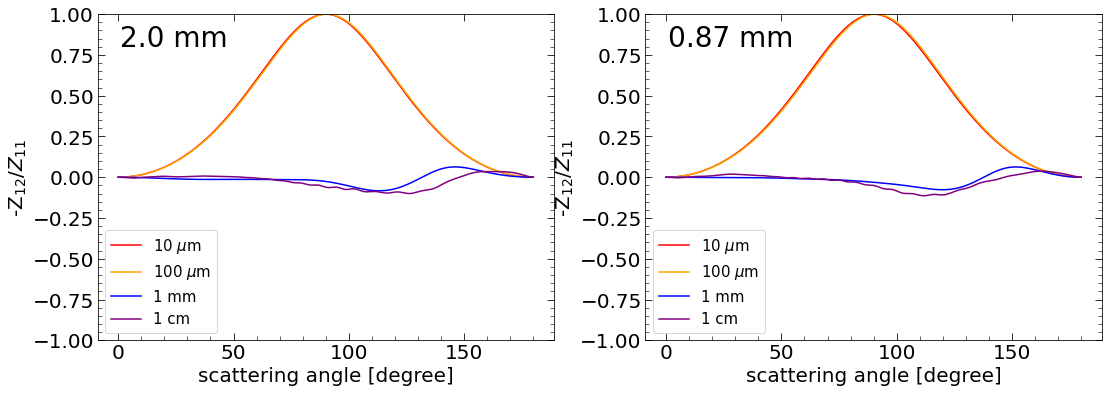

In [93]:
# Plotting
fig, ax = plt.subplots(1, 2, figsize=(18, 6))


for i in range(4):
    ax[0].plot(scatt_angles_deg, P_eff[:, 0, :][i], color = kataoka_fig2_colors[i], label = fig2_labels[i])
    ax[1].plot(scatt_angles_deg, P_eff[:, 1, :][i], color = kataoka_fig2_colors[i], label = fig2_labels[i])

# Add titles
# Titles
# for i in range(2):
#     ax[i].set_title(rf'$\lambda$ = {lambda_mm[fig2_bands[i]]}mm (ALMA Band {fig2_bands[i]})', fontsize=title_fs)

# Adjust ticks
for i in range(2):
    # Set axis labels
    ax[i].set_ylabel('-Z$_{12}/Z_{11}$', fontsize = axis_label_fs)
    ax[i].set_xlabel('scattering angle [degree]', fontsize = axis_label_fs)
    
    # Axis ticks
    ax[i].minorticks_on()
    
    ax[i].tick_params(axis="x", which="minor", direction="in", left=True, right=True, length=4)
    ax[i].tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4)


    ax[i].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)

    # Add a legend
    ax[i].legend(fontsize = legend_text_fs, loc = 'lower left')
    
    # Set y-lim
    ax[i].set_ylim(-1, 1)
    
    ax[i].text(0.05, 0.90,
           f"{constants.lambda_mm[fig2_bands[i]]} mm",
           transform=ax[i].transAxes,
           fontsize=text_fs)

    
    
    
plt.savefig(writeup_image_folder_path + '/DustModels/'+ "Kataoka2015Fig2.pdf", 
            dpi=300, 
            bbox_inches='tight')  



# plt.savefig(slideshow_image_folder_path + '/DustModels/'+ "Kataoka2015Fig2.jpeg", 
#             dpi=500, 
#             bbox_inches='tight')  

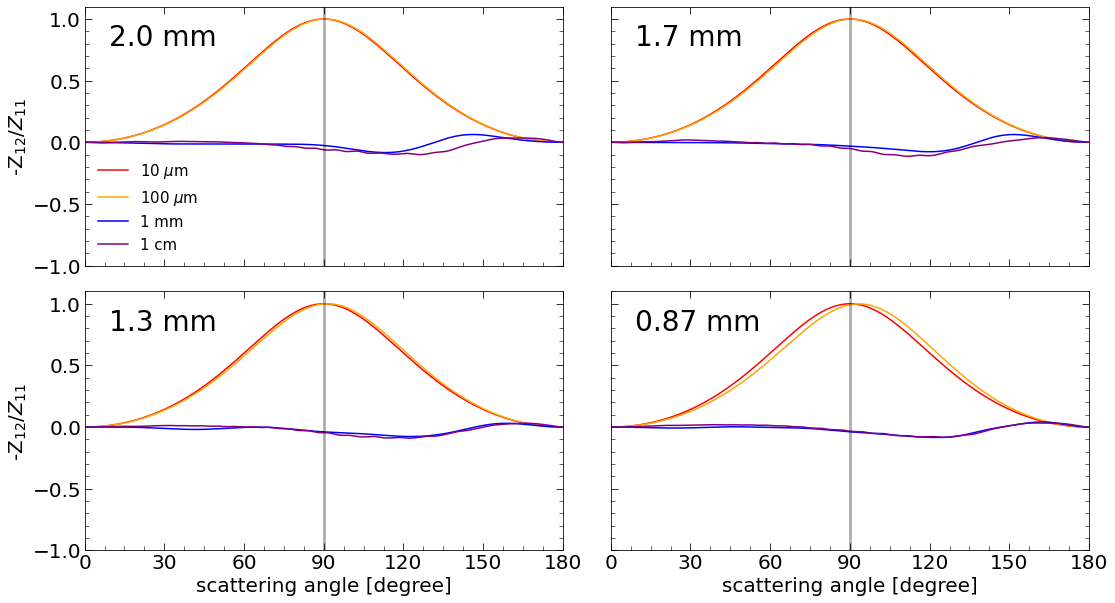

In [92]:
bands_fis2_all  = [4, 5, 6, 7]# Make the figure size


fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex = True, sharey = True)

flat_axes = axes.flatten()

for j, ax in enumerate(flat_axes):
    for i in range(4):
        
        # PLot the data 
        ax.plot(
            scatt_angles_deg,
            P_eff[:, j, :][i],
            color=kataoka_fig2_colors[i],
            label=fig2_labels[i]
        )
        
        
#     # Title
#     ax.set_title(rf'$\lambda$ = {lambda_mm[bands_fis2_all[j]]}mm (ALMA Band {bands_fis2_all[j]})', fontsize=title_fs)


    # Set axis labels
    # ------------------------------------------------------------------
    if j in (0, 2):
        ax.set_ylabel('-Z$_{12}/Z_{11}$', fontsize = axis_label_fs)
    # ------------------------------------------------------------------
    if j in (2, 3):
        ax.set_xlabel('scattering angle [degree]', fontsize = axis_label_fs)
    # ------------------------------------------------------------------
    
    # Axis ticks
    ax.minorticks_on()
    
    ax.tick_params(axis="x", which="minor", direction="in", left=True, right=True, length=4)
    ax.tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4)


    ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
    ax.tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)

    # Add a legend
    if j == 0:
        ax.legend(fontsize = legend_text_fs, loc = 'lower left', frameon = False)
    
    # Set x- and y-lims
    ax.set_xlim(0, 180)
    ax.set_xticks([0, 30, 60, 90, 120, 150, 180])
    ax.set_ylim(-1, 1.1)
    
        # Add a title
    ax.text(0.05, 0.85,
           f"{constants.lambda_mm[bands_fis2_all[j]]} mm",
           transform=ax.transAxes,
           fontsize=text_fs)
    
    
    # Add. vertical line at theta = 90
    ax.axvline(90, color = 'black', alpha = 0.3, lw = 3)
    
    

fig.subplots_adjust(
    wspace=0.1,  # horizontal space
    hspace=0.1   # vertical space
)
    
    
    
plt.savefig(writeup_image_folder_path + '/DustModels/'+ "Kataoka2015Fig2.pdf", 
            dpi=300, 
            bbox_inches='tight')  



# plt.savefig(slideshow_image_folder_path + '/DustModels/'+ "Kataoka2015Fig2.jpeg", 
#             dpi=500, 
#             bbox_inches='tight')  

### Step 5: Figure 3 — P vs a_max (at θ = 90°)

In [23]:
fig3_bands = ['Band 4 nterms2', 'Band 7 nterms2']  # or [7, 6] or whatever combo you want
fig3_indices = [bands.index(b) for b in fig3_bands]

In [24]:

# bins = 10

# fig, ax = plt.subplots(2, 2, figsize=(18, 10))

# ax[0, 0].hist(a_max_dist_cm,     bins = bins, color = 'blue')
# ax[0, 1].hist(a_max_dist_cm,     bins = bins, color = 'blue')
# ax[1, 0].hist(a_max_dist_cm,                bins = bins, color = 'pink')
# ax[1, 1].hist(a_max_dist_cm,                bins = bins, color = 'pink')


# # Make axes log if needed
# ax[0, 1].set_xscale('log')
# ax[1, 1].set_yscale('log')

# for i in range(2):
#     for j in range(2):
#         # Add axis labels
#         ax[i, j].set_xlabel('Wavelength', fontsize=axis_label_fs)
#         ax[i, j].set_ylabel('Count', fontsize=axis_label_fs)


#         # Adjust ticks
#         ax[i, j].minorticks_on()
#         ax[i, j].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
#         ax[i, j].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)

#         # Remove scientific notation from x-axis
#         ax[i, j].xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
#         ax[i, j].ticklabel_format(style='plain', axis='x')
        
# # Add spacing between subplots
# plt.subplots_adjust(wspace=0.4)
# plt.subplots_adjust(hspace=0.4)

In [25]:
P, omega, P_times_omega = compute_P_and_omega_vs_amax(lambda_bands_cm, a_max_dist_cm, zscat, res_scatter, theta)

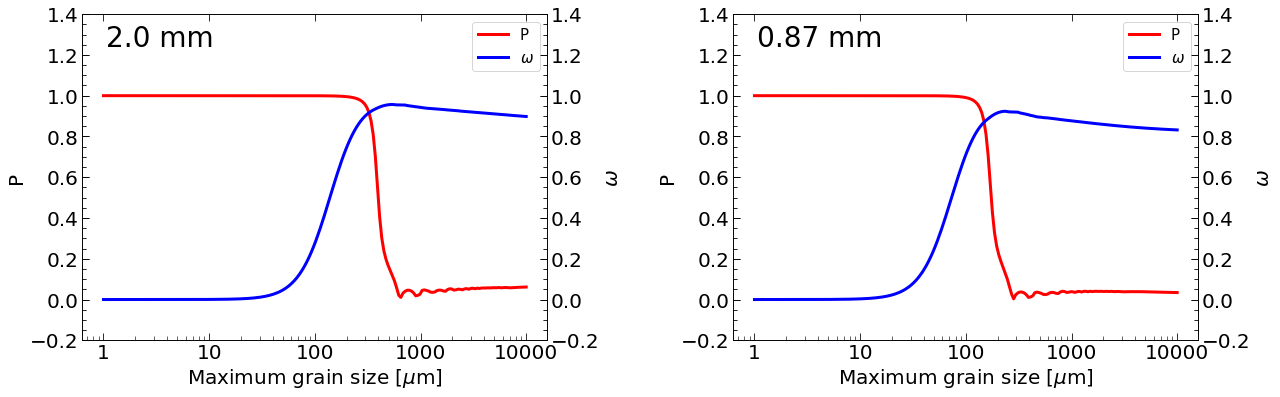

In [89]:
# Plotting
fig, ax = plt.subplots(1, 2, figsize=(20, 6))  # Wider figure for spacing

# Create secondary y-axes
ax2_0 = ax[0].twinx()
ax2_1 = ax[1].twinx()

# Plot on the left
ax0_P,     = ax[0].plot(a_max_dist_micron, P[:, fig3_indices[0]],    color='red', label='P', lw = 3)
ax0_omega, = ax2_0.plot(a_max_dist_micron, omega[:, fig3_indices[0]], color='blue', label=r'$\omega$', lw = 3)

# Plot on the right
ax1_P,     = ax[1].plot(a_max_dist_micron, P[:, fig3_indices[1]], color='red', label='P', lw = 3)
ax1_omega, = ax2_1.plot(a_max_dist_micron, omega[:, fig3_indices[1]], color='blue', label=r'$\omega$', lw = 3)

# Titles
for i in range(2):
#     ax[i].set_title(rf'$\lambda$ = {lambda_mm[fig3_bands[i]]}mm (ALMA {fig3_bands[i]})', fontsize=title_fs)
    ax[i].set_xlabel('Maximum grain size [$\mu$m]', fontsize=axis_label_fs)
    ax[i].set_ylabel('P', fontsize=axis_label_fs)
    
    
        # Make axes log if needed
    ax[i].set_xscale('log')
#     ax[i].set_yscale('log')

    # Remove scientific notation from x-axis
    ax[i].xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
    ax[i].ticklabel_format(style='plain', axis='x')
    

    ax[i].text(0.05, 0.90,
               f"{constants.lambda_mm[fig3_bands[i]]} mm",
               transform=ax[i].transAxes,
               fontsize=text_fs)

ax2_0.set_ylabel(r'$\omega$', fontsize=axis_label_fs)
ax2_1.set_ylabel(r'$\omega$', fontsize=axis_label_fs)

# Ticks
for a in [ax[0], ax[1], ax2_0, ax2_1]:
    a.minorticks_on()
    a.tick_params(axis="x", which="minor", direction="in", left=True, right=True, length=4)
    a.tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4)
    
    a.tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
    a.tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)

    a.set_ylim(-0.2, 1.4)


# Single legend per subplot
ax[0].legend(handles = [ax0_P, ax0_omega], fontsize = legend_text_fs, loc = 'upper right')
ax[1].legend(handles = [ax1_P, ax1_omega], fontsize = legend_text_fs, loc = 'upper right')

# Add spacing between subplots
plt.subplots_adjust(wspace=0.4)



plt.savefig(writeup_image_folder_path  + '/DustModels/'+ "P_vs_w_vs_grainsize.png", 
            dpi=300, 
            facecolor='white',
            bbox_inches='tight') 

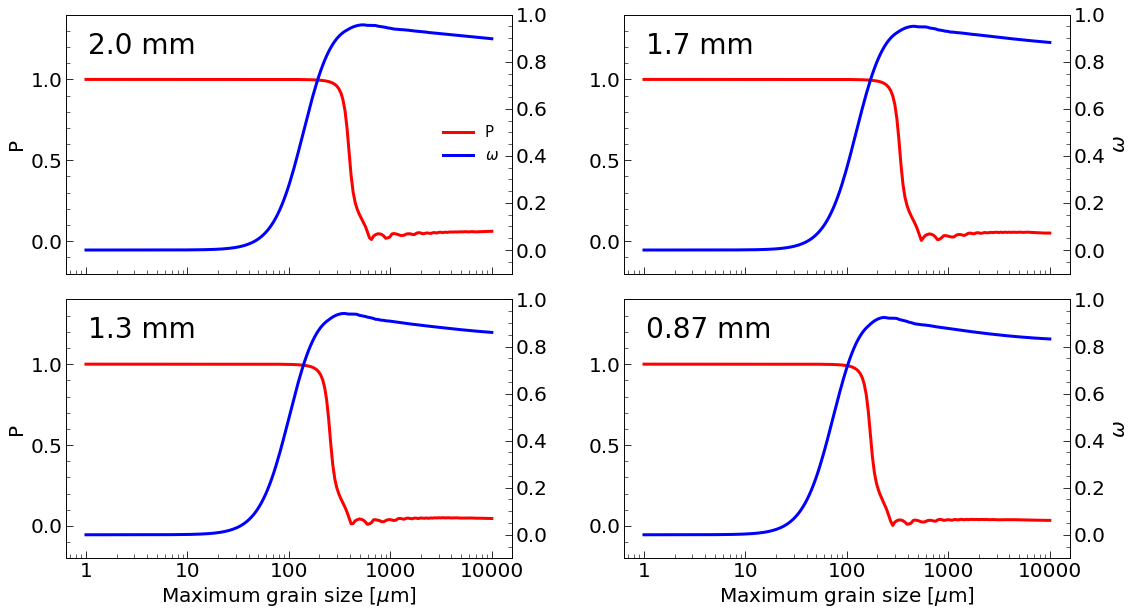

In [90]:
fig3_bands_grid = ['Band 4 nterms2', 'Band 5', 'Band 6', 'Band 7 nterms2']  # or [7, 6] or whatever combo you want
fig3_indices_grid = [bands.index(b) for b in fig3_bands_grid]


fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex = True)
axes = axes.flatten()

ax2_list = []  # store twin axes

for j, ax in enumerate(axes):

    # Create twin axis
    ax2 = ax.twinx()
    ax2_list.append(ax2)

    # Plot P
    line_P, = ax.plot(
        a_max_dist_micron,
        P[:, fig3_indices_grid[j]],
        color='red',
        label='P',
        lw=3
    )

    # Plot omega
    line_omega, = ax2.plot(
        a_max_dist_micron,
        omega[:, fig3_indices_grid[j]],
        color='blue',
        label=r'$\omega$',
        lw=3
    )

    # Labels
    if j in (2, 3):
        ax.set_xlabel('Maximum grain size [$\mu$m]', fontsize=axis_label_fs)
    if j in (0, 2):
        ax.set_ylabel('P', fontsize=axis_label_fs)

    if j in (1, 3):
        ax2.set_ylabel(r'$\omega$', fontsize=axis_label_fs)

    # Log x-axis
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
    ax.ticklabel_format(style='plain', axis='x')

    # Limits
    ax.set_ylim(-0.2, 1.4)
    ax2.set_ylim(-0.1, 1)

    # Title text
    ax.text(
        0.05, 0.85,
        f"{constants.lambda_mm[fig3_bands_grid[j]]} mm",
        transform=ax.transAxes,
        fontsize=text_fs
    )

    # Ticks (both axes)
    for a in [ax, ax2]:
        a.minorticks_on()
        a.tick_params(axis="x", which="minor", direction="in", length=4)
        a.tick_params(axis="y", which="minor", direction="in", length=4)

        a.tick_params(axis="x", which="major", direction="in", length=7, labelsize=axis_num_fs)
        a.tick_params(axis="y", which="major", direction="in", length=7, labelsize=axis_num_fs)

    # Legend (per subplot)
    if j == 0:
        ax.legend(handles=[line_P, line_omega],
                  fontsize=legend_text_fs,
                  loc='right',
                  frameon = False)

# Spacing
fig.subplots_adjust(wspace=0.25, hspace=0.1)


plt.savefig(writeup_image_folder_path  + '/DustModels/'+ "P_vs_w_vs_grainsize_grid.pdf", 
            dpi=300, 
            facecolor='white',
            bbox_inches='tight') 

In [88]:
slideshow_image_folder_path

"/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/WRITEUP_AND_IMAGES/IMAGES/SLIDESHOW/"

## Figure 4

In [27]:
top_label = []
bottom_label = []

for band in bands:
    top = f"{lambda_mm[band]} mm"
    bottom = f"(Band {band})"
    
    top_label.append(top)
    bottom_label.append(bottom)

At Band Band 4, the highest Pw value is 0.8610972091003367
At this Pw value, the a_max value is 296.73024081888695 micron
 
At Band Band 5, the highest Pw value is 0.8480528038185204
At this Pw value, the a_max value is 246.5811075822604 micron
 
At Band Band 6, the highest Pw value is 0.8281233419197942
At this Pw value, the a_max value is 195.63983435170647 micron
 
At Band Band 7, the highest Pw value is 0.796099522028225
At this Pw value, the a_max value is 135.09935211980266 micron
 


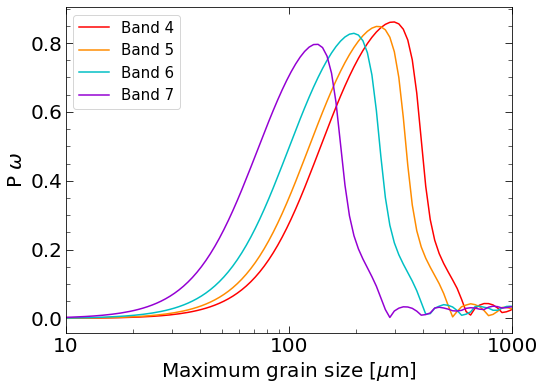

In [91]:
# mm

# Create a figure with the WCS projection
fig, ax = plt.subplots(figsize=(8, 6))
#                [B4,  B6,   B7]
# P_scale_factor = [1.15, 1.68, 1.2]

for i, band in enumerate(bands):
    ax.plot(a_max_dist_micron,
            P_times_omega[:, i],
            color = alma_band_colors[band],
            ls = '-',
            label = f'{bands_labels[i]}')
    
    
    # Find index of max Pw
    max_idx = np.argmax(P_times_omega[:, i])

    max_val = P_times_omega[max_idx, i]
    amax_at_max = a_max_dist_micron[max_idx]

    print(f'At Band {bands_labels[i]}, the highest Pw value is {max_val}')
    print(f'At this Pw value, the a_max value is {amax_at_max} micron')
    print(' ')


# Add axis labels
ax.set_xlabel('Maximum grain size [$\mu$m]', fontsize=axis_label_fs)
ax.set_ylabel('P $\omega$', fontsize=axis_label_fs)


# Adjust ticks
ax.minorticks_on()

ax.tick_params(axis="x", which="minor", direction="in", left=True, right=True, length=4)
ax.tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4)
    
ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True,   length=7, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="major", direction="in", left=True,   right=True, length=7, labelsize=axis_num_fs)



# Make axes log if needed
ax.set_xscale('log')
# ax.set_yscale('log')

# Remove scientific notation from x-axis
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
ax.ticklabel_format(style='plain', axis='x')

# ---------------------------------------------------------------------------------
ax.legend(fontsize = legend_text_fs)
# ---------------------------------------------------------------------------------
# fs = 15
# x_offset = [2, 1, 1]

# for i in range(1):
#     y_loc = np.max(P_times_omega[:, i])
#     idx = np.argmax(P_times_omega[:, i])
#     x_loc = a_max_dist_micron[idx]

#     # Offset value can be tuned depending on your data scale
#     ax.text(x_loc * x_offset[i], y_loc + 0.1,  # top label slightly above peak
#             top_label[i],
#             color=band_colors[i],
#             fontsize=fs,
#             ha='center')

#     ax.text(x_loc * x_offset[i], y_loc + 0.01,  # bottom label at peak
#             bottom_label[i],
#             color=band_colors[i],
#             fontsize=fs,
#             ha='center')
 # ---------------------------------------------------------------------------------   
    
# Add horizontal lines of POLF_avg at each band if my own data
# for i in range(num_bands):
#     ax.axhline(POLF_avg[i], color = band_colors[i], ls = '--', lw = 3)

# ax.set_ylim(-0.1, 1.5)

ax.set_xlim(10, 1000)

# ax.axhline(0.8, color = 'black', ls = '--', lw = 3)



plt.savefig(writeup_image_folder_path  + '/DustModels/'+ "Pw_vs_grainsize.pdf", 
            dpi=300, 
            facecolor='white',
            bbox_inches='tight') 

In [29]:
POLF_avg

[]

At 200 microns:

Pw is 100% polarized
Band 4: Pw ~ 0.86 

Band 6: Pw ~ 0.83

Band 7: Pw ~ 0.8 

PW is 100% polarized


POLF is POLF% polarized
Band 4: POLF ~ 1

Band 6: POLF ~ 1.4

Band 7: POLF ~ 0.65

Changing facor of ~ 0.0175

Band 4: Pw * factor = ~ 0.86 * 0.0175 = 1.5% (1.2% is too high)

Band 6: Pw * factor ~ 0.83 * 0.0175 = 1.4525% (what we want)

Band 7: Pw * factor ~ 0.8  * 0.0175 = 1.4% (should be around 0.875)

In [30]:
0.86* 0.0175 * 100

1.5050000000000001

In [31]:
0.0175*100

1.7500000000000002